<a href="https://colab.research.google.com/github/SherifJR/forFun/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
pip install insightface

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 8.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 93.4 MB/s eta 0:00:00
  Created wheel for insightface: filename=insightface-0.7.3-cp312-cp312-linux_x86_64.whl size=1071494 sha256=1e6ed08e9e0780501d675ba68e0f13332a245d653e1d4d5f9bb65169f5311b81
  Stored in directory: /root/.cache/pip/wheels/73/3c/e2/6d4815e8a8b33a2006554d65ce0d1f973e768f4c7a222fa675
Successfully built insightface


In [29]:
import os
import numpy as np
np.int = int
from numpy.linalg import norm
import cv2
from matplotlib import pyplot as plt
import insightface
from insightface.app import FaceAnalysis
from insightface.data import get_image as ins_get_image

/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)


True

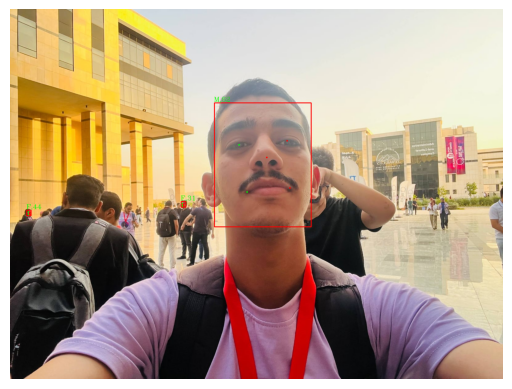

In [30]:
app = FaceAnalysis(name="buffalo_l")
app.prepare(ctx_id=0, det_size=(640, 640))

img=cv2.imread("/content/sherif4.jpeg")
faces=app.get(img)

rimg=app.draw_on(img, faces)
plt.imshow(cv2.cvtColor(rimg, cv2.COLOR_BGR2RGB))
plt.axis("off")
cv2.imwrite("sherif_output.jpg", rimg)

In [31]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
from tqdm import tqdm
import pickle
import os
import cv2

Dataset_dir = "/content/drive/MyDrive/lfw_funneled"
known_embeddings = []
known_names = []

people = [d for d in os.listdir(Dataset_dir) if os.path.isdir(os.path.join(Dataset_dir, d))]

people = people[:100]

print(f"Processing {len(people)} people...")

for person_name in tqdm(people, desc="Processing people"):
    person_dir = os.path.join(Dataset_dir, person_name)

    img_count = 0
    max_images = 1

    for img_name in os.listdir(person_dir):
        if img_count >= max_images:
            break

        img_path = os.path.join(person_dir, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue

        faces = app.get(img)
        if len(faces) == 0:
            print(f"no face in {img_path}")
            continue

        known_embeddings.append(faces[0].embedding)
        known_names.append(person_name)
        img_count += 1

print(f"\nLoaded {len(known_embeddings)} embeddings for {len(set(known_names))} unique people")

with open('/content/drive/MyDrive/face_embeddings.pkl', 'wb') as f:
    pickle.dump({'embeddings': known_embeddings, 'names': known_names}, f)
print("Embeddings saved to face_embeddings.pkl")

Processing 100 people...


Processing people: 100%|██████████| 100/100 [02:08<00:00,  1.29s/it]


Loaded 100 embeddings for 100 unique people
Embeddings saved to face_embeddings.pkl


In [33]:
import pickle
import cv2
import numpy as np
from insightface.app import FaceAnalysis

app.prepare(ctx_id=0)

with open('/content/drive/MyDrive/face_embeddings.pkl', 'rb') as f:
    data = pickle.load(f)
    known_embeddings = np.array(data['embeddings'])
    known_names = data['names']

print(f"Loaded {len(known_embeddings)} embeddings")

set det-size: (640, 640)
Loaded 100 embeddings


In [48]:
def cosine_similarity(a, b):
    return np.dot(a, b) / (norm(a) * norm(b))

def recognize_face(test_image_path, threshold=0.4):

    test_img = cv2.imread(test_image_path)

    if test_img is None:
        print(f"Error: Could not load image from {test_image_path}")
        return []

    test_faces = app.get(test_img)

    if len(test_faces) == 0:
        print("No faces detected in the image")
        return []

    results = []

    for idx, face in enumerate(test_faces):
        test_embedding = face.embedding

        similarities = [cosine_similarity(test_embedding, known_emb)
                       for known_emb in known_embeddings]

        best_match_idx = np.argmax(similarities)
        best_similarity = similarities[best_match_idx]

        if best_similarity > threshold:
            recognized_name = known_names[best_match_idx]
            results.append({
                'face_num': idx + 1,
                'name': recognized_name,
                'confidence': best_similarity
            })
        else:
            results.append({
                'face_num': idx + 1,
                'name': 'Unknown',
                'confidence': best_similarity
            })

    return results

test_image_path = "/content/leaf.png"
results = recognize_face(test_image_path)

for result in results:
    print(f"Face {result['face_num']}: {result['name']} (confidence: {result['confidence']:.3f})")

Face 1: Unknown (confidence: 0.181)


In [45]:
import pickle
import random

# Load data
with open('/content/drive/MyDrive/face_embeddings.pkl', 'rb') as f:
    data = pickle.load(f)

# Get random people to test
unique_people = list(set(data['names']))
sample_people = random.sample(unique_people, min(5, len(unique_people)))

print("🎲 Random people you can test with:")
for person in sample_people:
    print(f"  - {person}")

# Or get people with most images (best for testing)
from collections import Counter
name_counts = Counter(data['names'])
top_people = [name for name, count in name_counts.most_common(5)]

print("\n⭐ People with most images (best for testing):")
for person in top_people:
    print(f"  - {person} ({name_counts[person]} images)")

🎲 Random people you can test with:
  - Franklin_Damann
  - Juanes
  - Jean-Francois_Lemounier
  - Larry_Thompson
  - Lloyd_Mudiwa

⭐ People with most images (best for testing):
  - Carlos_Ruckauf (1 images)
  - Bill_Belichick (1 images)
  - Zarai_Toledo (1 images)
  - Ryan_Leaf (1 images)
  - Tsutomu_Takebe (1 images)
